# Exploratory Data Analysis (EDA)


## 1. Import Libraries
**Analisis:** Mengimpor seluruh pustaka (library) standar yang dibutuhkan untuk manipulasi data (Pandas, Numpy) dan visualisasi data (Matplotlib, Seaborn).


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## 2. Load Dataset
**Analisis:** Memuat dataset dan menampilkan 5 baris pertama. Terlihat bahwa dataset ini berisi rekaman penggunaan energi yang diambil setiap interval 15 menit, mencakup fitur numerik (listrik, CO2) dan kategorikal (hari, beban).


In [34]:
df = pd.read_csv('Steel_industry.csv')
df.head()


,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_Of_Week,Load_Type
0,01-01-2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01-01-2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01-01-2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01-01-2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01-01-2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


## 3. Data Information
**Analisis:** Dataset memiliki 35.041 baris dan 11 kolom. Terlihat bahwa tidak ada nilai kosong (Non-Null Count = 35041) pada seluruh kolom. Kolom Date_Time masih bertipe teks (object) dan harus diubah menjadi tipe datetime nanti.


In [35]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 35041 entries, 0 to 35040
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date_Time                             35041 non-null  str    
 1   Usage_kWh                             35041 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35041 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35041 non-null  float64
 4   CO2(tCO2)                             35041 non-null  float64
 5   Lagging_Current_Power_Factor          35041 non-null  float64
 6   Leading_Current_Power_Factor          35041 non-null  float64
 7   NSM                                   35041 non-null  int64  
 8   WeekStatus                            35041 non-null  str    
 9   Day_Of_Week                           35041 non-null  str    
 10  Load_Type                             35041 non-null  str    
dtypes: float64(6), int64(1), s

## 4. Summary Statistics
**Analisis:** Ringkasan statistik menunjukkan nilai minimum, maksimum, dan rata-rata setiap fitur numerik. Terdapat perbedaan signifikan antara nilai rata-rata dan nilai maksimum pada beberapa fitur (seperti Usage_kWh dan CO2), yang memberikan petunjuk awal adanya _outlier_ (pencilan) bernilai besar yang kemungkinan terjadi pada saat jam beban puncak (Maximum Load).


In [36]:
df.describe()


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35041.000000,35041.000000,35041.000000,35041.000000,35041.000000,35041.000000,35041.000000
mean,27.386229,13.035012,3.871412,0.011524,80.578610,84.366038,42750.834736
std,33.444133,16.305916,7.424863,0.016151,18.921337,30.458030,24940.667915
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21600.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,43200.000000
75%,51.230000,22.640000,2.090000,0.020000,99.030000,100.000000,64800.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


## 5. Check Missing Values
**Analisis:** Secara spesifik memastikan ulang ketiadaan _missing value_ (data kosong/null). Hasilnya nol untuk semua fitur, sehingga kita tidak perlu melakukan teknik imputasi pengisian data yang hilang.


In [37]:
df.isnull().sum()


Date_Time                               0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_Of_Week                             0
Load_Type                               0
dtype: int64

## 6. Check Duplicates
**Analisis:** Memeriksa keberadaan baris yang terduplikasi. Baris yang isinya sama persis dapat membuat model overfit atau bias, sehingga nanti harus dihapus jika jumlahnya signifikan.


In [38]:
print('Number of duplicates:', df.duplicated().sum())


Number of duplicates: 0


## 7. Numerical Feature Distributions
**Analisis:** Dari visualisasi histogram, terlihat jelas bahwa fitur-fitur numerik (seperti Usage_kWh, emisi CO2, dll.) **TIDAK berdistribusi normal**. Bentuk datanya menceng ke kanan (Right-skewed) atau bersifat bimodal/multimodal, yang sangat wajar karena operasional pabrik akan melonjak tinggi hanya pada jam/kondisi beban puncak tertentu.


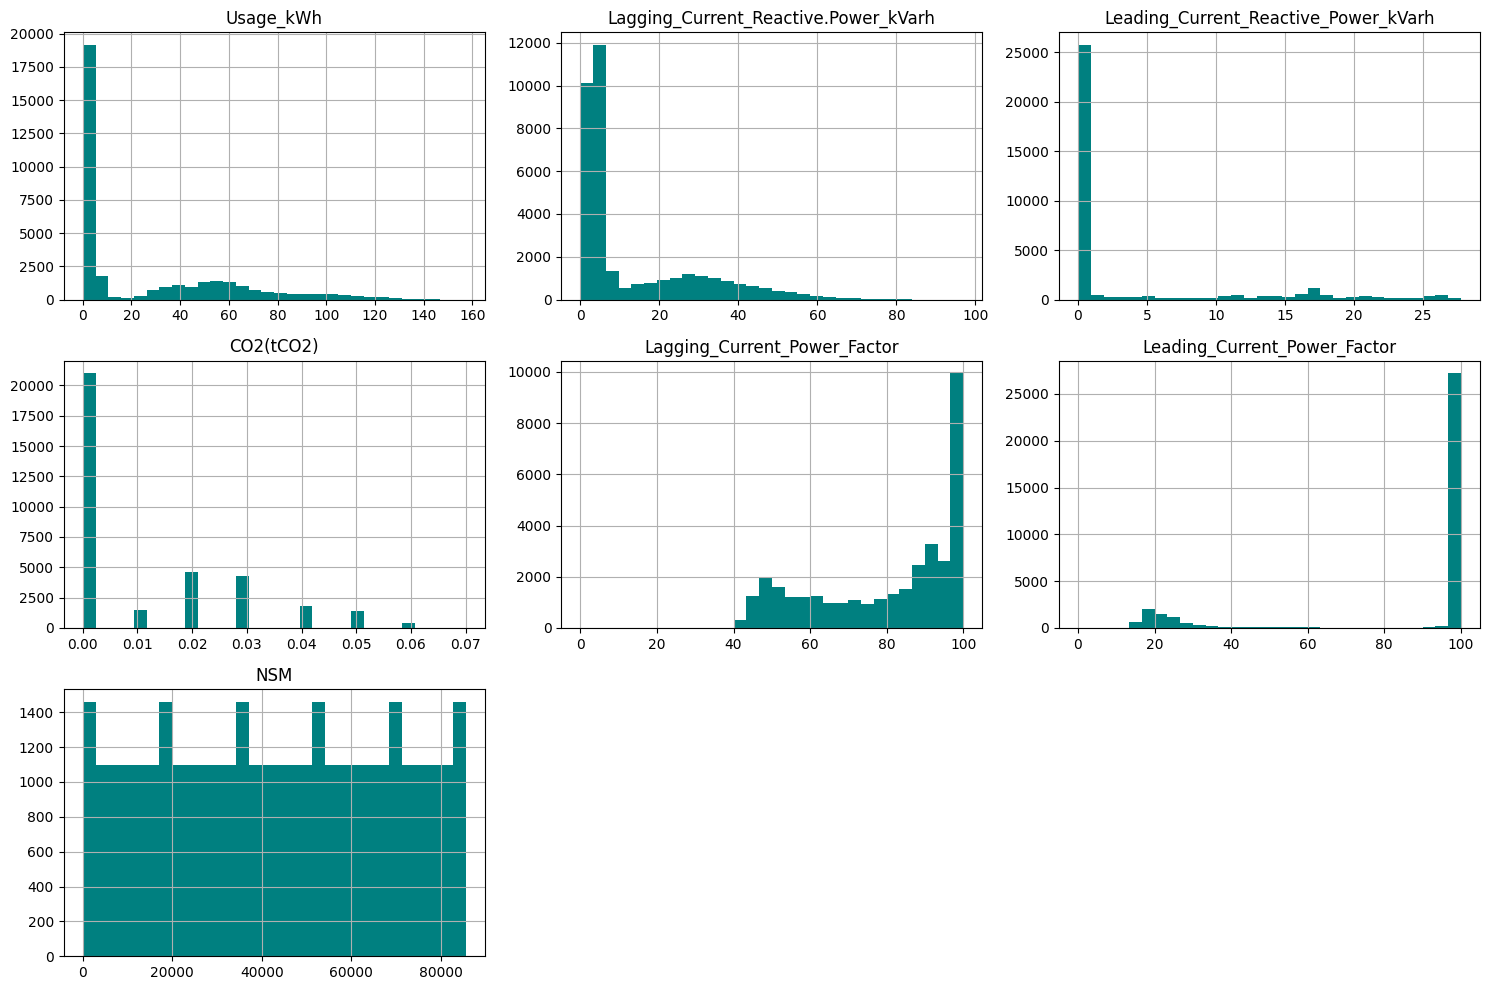

In [39]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_cols].hist(figsize=(15, 10), bins=30, color='teal')
plt.tight_layout()
plt.show()


## 8. Categorical Feature Distributions
**Analisis:** Dari grafik Countplot, operasional (rekaman data) lebih banyak terjadi pada Weekday (hari kerja). Distribusi hari (Day_Of_Week) cukup berimbang (seimbang tiap harinya). Untuk tipe beban (Load_Type), pabrik baja ini menghabiskan waktu paling banyak di Light_Load dibandingkan Maximum_Load.


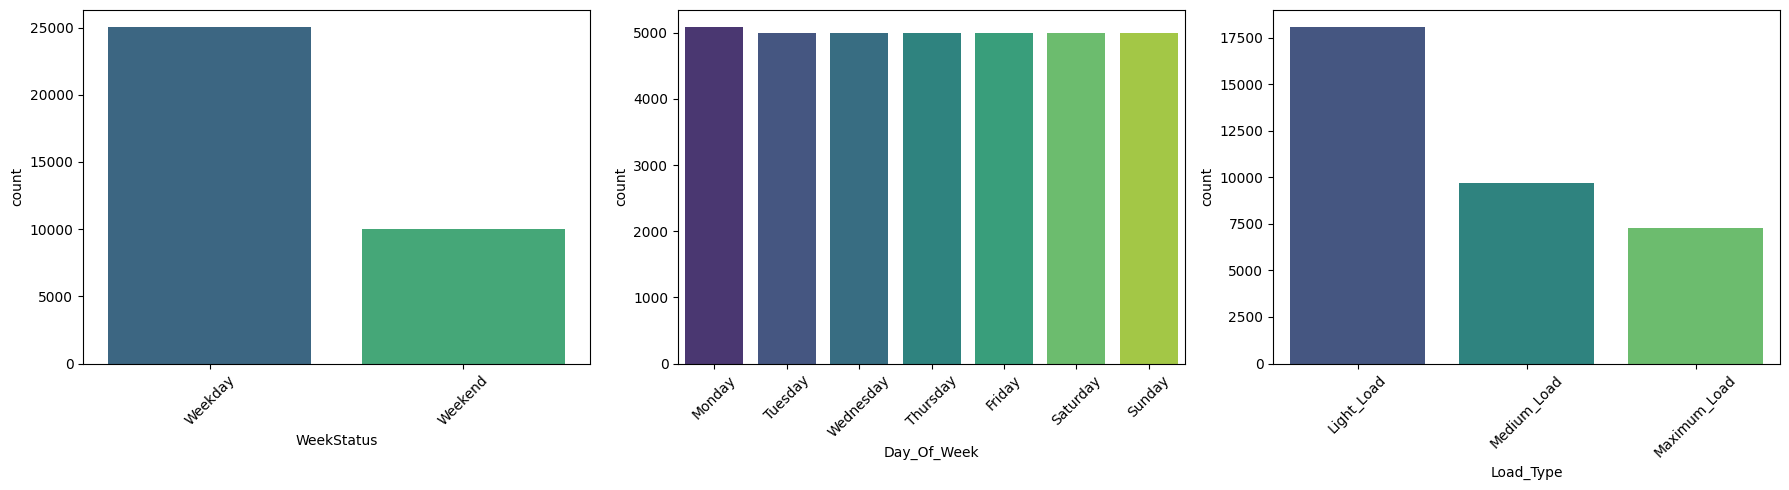

In [40]:
categorical_cols = ['WeekStatus', 'Day_Of_Week', 'Load_Type']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='viridis')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## 8.1 Visualisasi Outlier (Boxplot)
**Analisis:** Terlihat banyak titik hitam yang berada di atas garis whisker teratas. Hal ini mengonfirmasi adanya _outlier_ positif. Namun, untuk kasus konsumsi listrik industri, _outlier_ ini adalah kejadian nyata (valid) di mana pabrik menyedot daya ekstra besar saat _Maximum_Load_, sehingga kita **tidak boleh menghapusnya** agar model bisa memprediksi lonjakan tersebut.


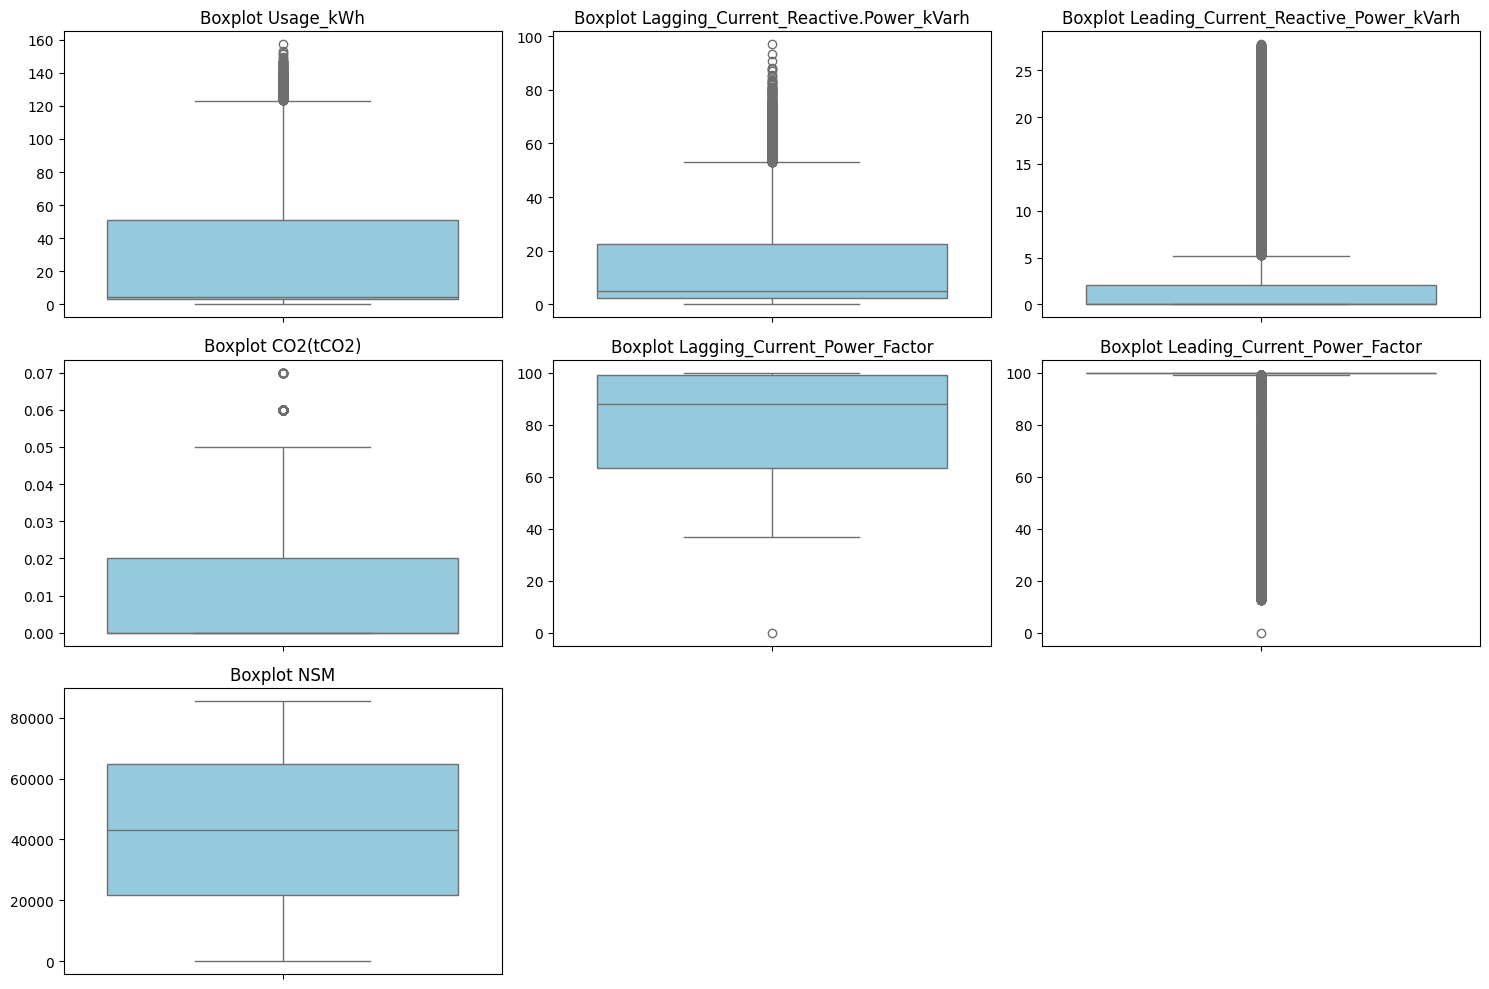

In [41]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()


## 8.2 Visualisasi Persebaran Data (Pairplot)
**Analisis:** Visualisasi ini membuktikan secara visual adanya hubungan linier dan non-linier antar fitur. Kurva diagonal (KDE) menegaskan kembali bahwa fitur-fitur tidak berdistribusi normal lonceng.


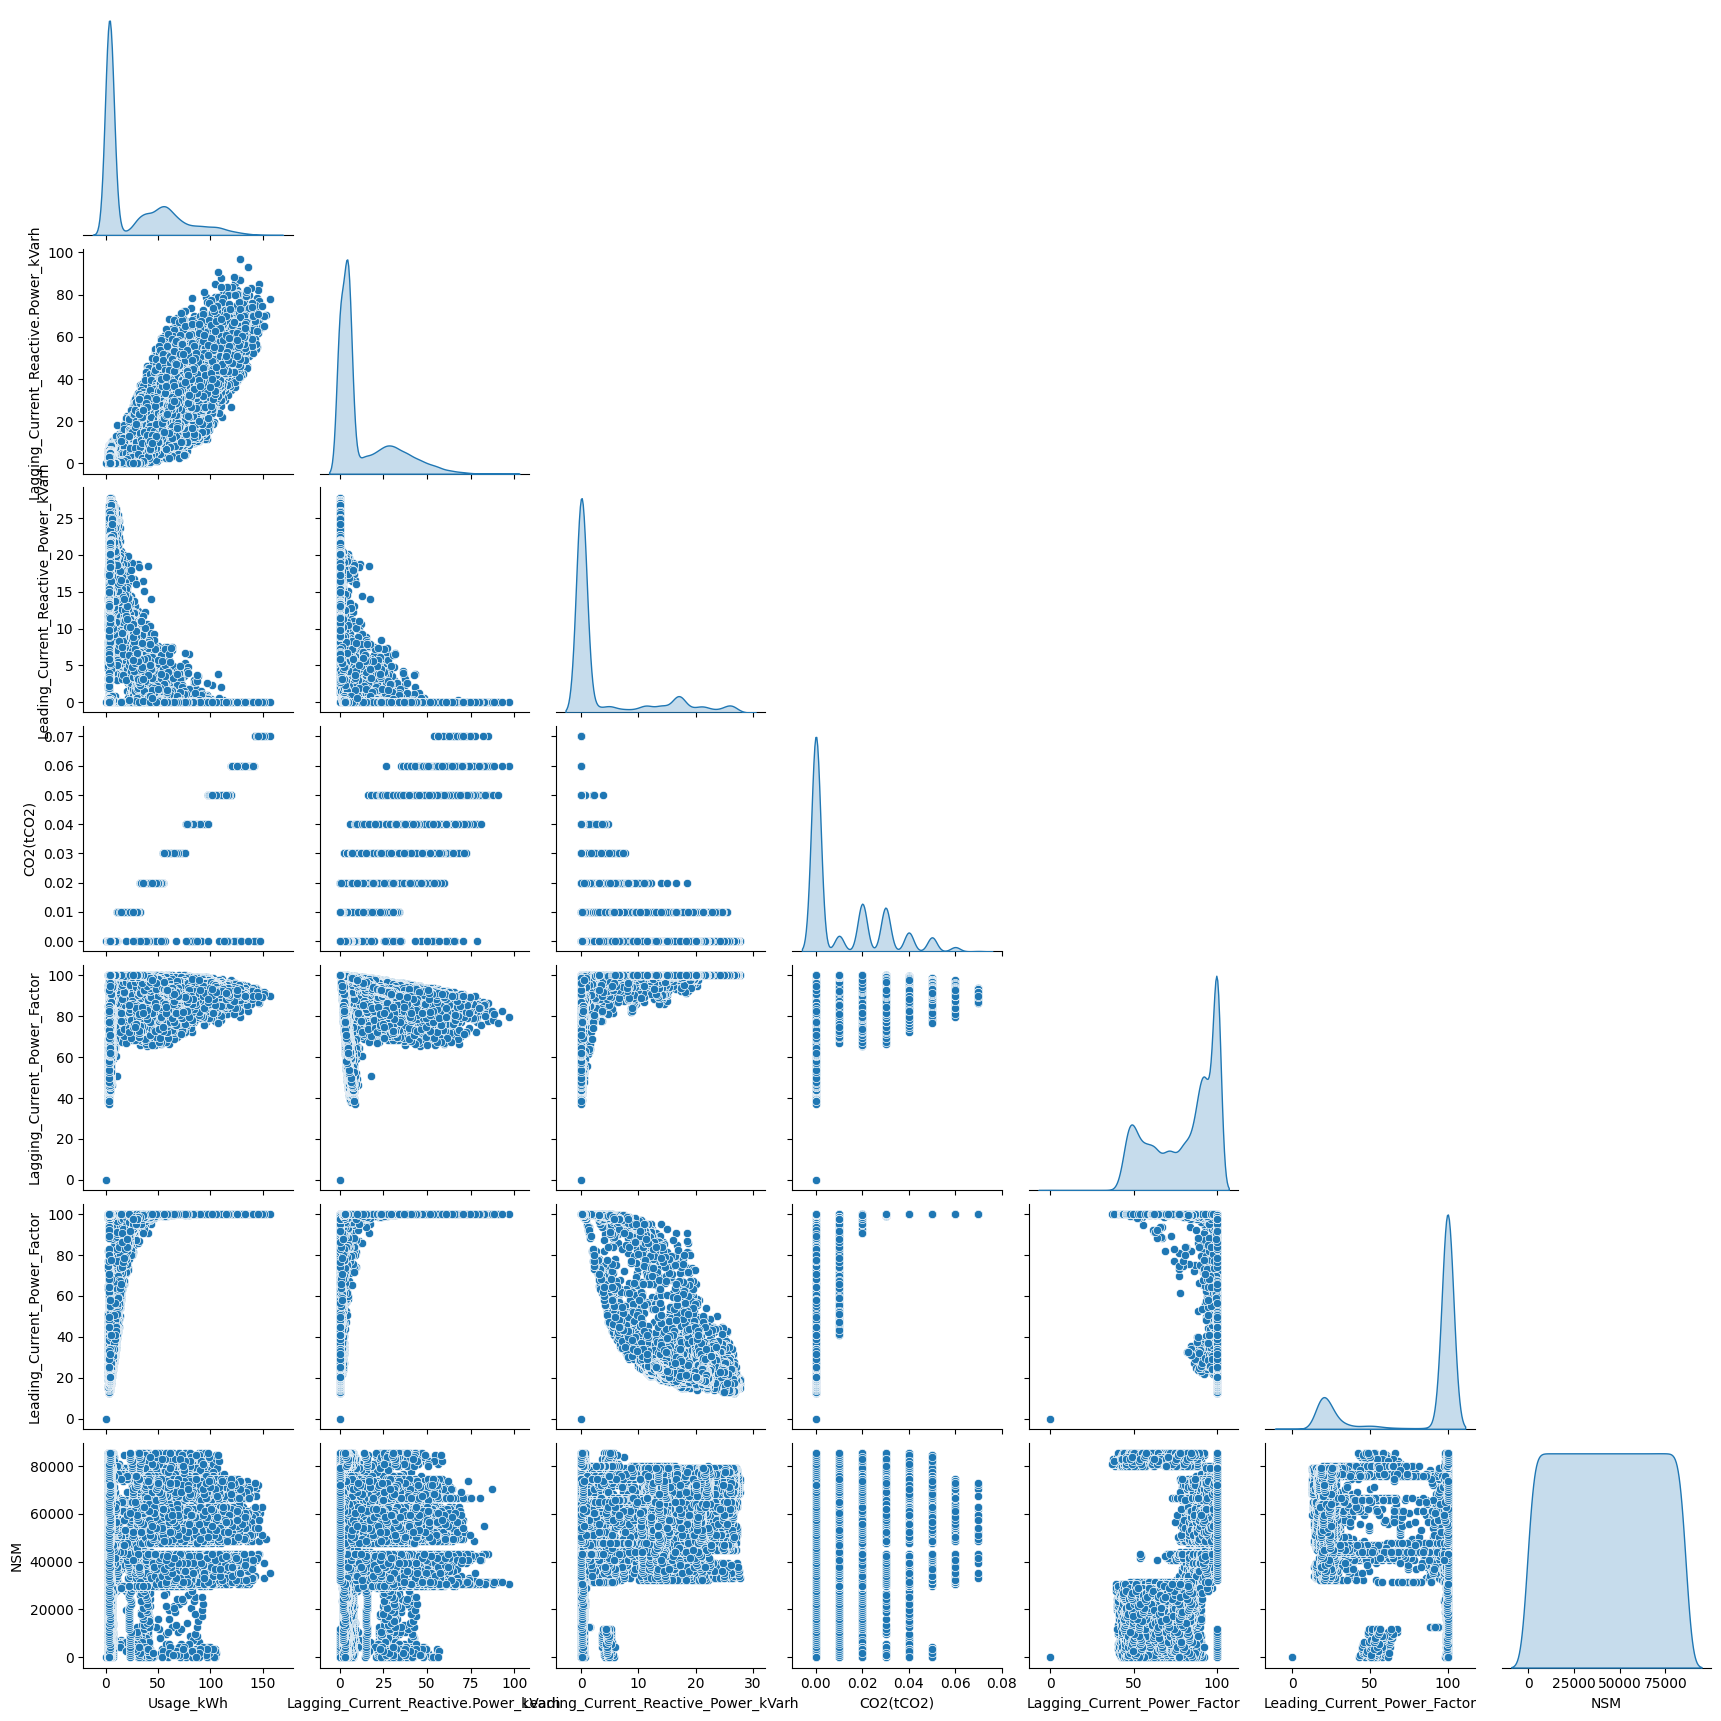

In [42]:
sns.pairplot(df[numerical_cols], corner=True, diag_kind='kde')
plt.show()


## 9. Correlation Matrix
**Analisis:** Heatmap menunjukkan korelasi Pearson. Terlihat bahwa Usage_kWh memiliki korelasi positif yang mendekati absolut (sangat kuat) dengan CO2(tCO2). Hal ini logis: semakin tinggi pemakaian listrik mesin baja, emisi CO2 yang dihasilkan pun melonjak sejalan. Nilai NSM juga memperlihatkan korelasi sedang yang dapat membantu model.


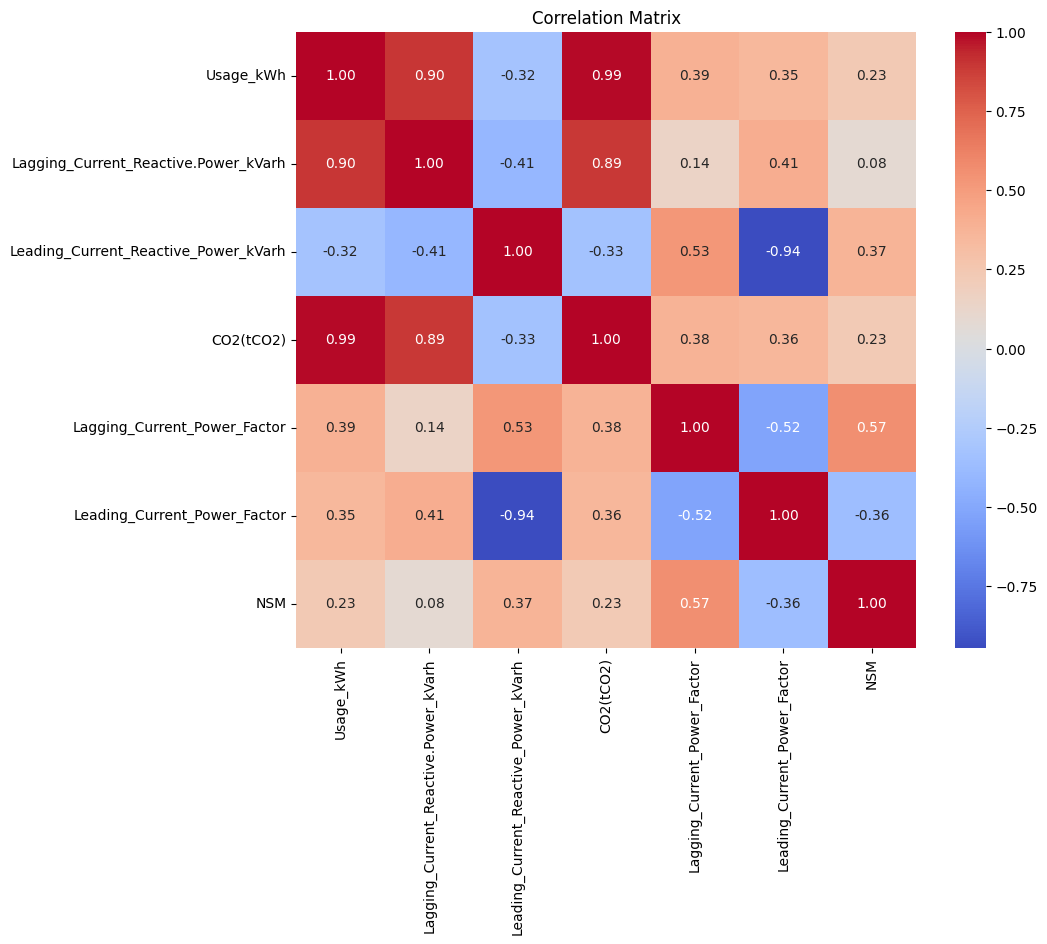

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


# Data Preprocessing


## 10. Handle Date_Time Feature
**Analisis:** Fitur Date_Time tidak bisa dicerna langsung oleh model secara algoritmik. Kita harus mengekstraknya menjadi Tahun, Bulan, Hari, Jam, dan Menit. Dengan ini, model bisa menangkap pola musiman atau pola harian jam operasional.


In [44]:
# Convert to datetime
df['Date_Time'] = pd.to_datetime(df['Date_Time'], format='%d-%m-%Y %H:%M')

# Extract useful datetime features
df['Year'] = df['Date_Time'].dt.year
df['Month'] = df['Date_Time'].dt.month
df['Day'] = df['Date_Time'].dt.day
df['Hour'] = df['Date_Time'].dt.hour
df['Minute'] = df['Date_Time'].dt.minute

# Drop the original Date_Time column
df = df.drop('Date_Time', axis=1)
df.head()


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_Of_Week,Load_Type,Year,Month,Day,Hour,Minute
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018,1,1,0,15
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018,1,1,0,30
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018,1,1,0,45
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,2018,1,1,1,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,2018,1,1,1,15


## 11. Handle Duplicates
**Analisis:** Kita membuang baris yang nilainya sama kembar untuk mencegah redundant pattern agar model machine learning bisa belajar dengan lebih stabil tanpa bias frekuensi tiruan.


In [45]:
# Drop duplicate rows
df = df.drop_duplicates()
print('Duplicates after dropping:', df.duplicated().sum())


Duplicates after dropping: 0


## 12. Encode Categorical Features
**Analisis:** Fitur yang tadinya berisi teks deskriptif (seperti Monday, Weekday, Light_Load) di-_encode_ menggunakan LabelEncoder agar berubah menjadi angka/numerik representatif yang bisa dikalkulasi oleh algoritma matriks pada Machine Learning.


In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['WeekStatus'] = le.fit_transform(df['WeekStatus'])
df['Day_Of_Week'] = le.fit_transform(df['Day_Of_Week'])
df['Load_Type'] = le.fit_transform(df['Load_Type'])

df.head()


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_Of_Week,Load_Type,Year,Month,Day,Hour,Minute
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1,0,2018,1,1,0,15
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1,0,2018,1,1,0,30
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1,0,2018,1,1,0,45
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,0,1,0,2018,1,1,1,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,0,1,0,2018,1,1,1,15


## 13. Feature Scaling
**Analisis:** Karena tiap fitur memiliki satuan ukur berbeda (kWh, kVArh, persentase dll.) dan magnitude-nya bervariasi luas, maka dilakukan standarisasi (Z-score normalization) dengan StandardScaler. Proses ini membuat rata-rata fitur menjadi 0 dan standar deviasi menjadi 1. Hal ini wajib dilakukan terutama jika model menggunakan perhitungan jarak spasial/vektor.


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale the original numerical features
cols_to_scale = ['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 
                 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Usage_kWh']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df.head()


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_Of_Week,Load_Type,Year,Month,Day,Hour,Minute
0,-0.724090,-0.618497,-0.521419,-0.713535,-0.389439,0.513303,-1.678040,0,1,0,2018,1,1,0,15
1,-0.699273,-0.525891,-0.521419,-0.713535,-0.729801,0.513303,-1.641954,0,1,0,2018,1,1,0,30
2,-0.721997,-0.598258,-0.521419,-0.713535,-0.544293,0.513303,-1.605867,0,1,0,2018,1,1,0,45
3,-0.719904,-0.581086,-0.521419,-0.713535,-0.660037,0.513303,-1.569781,0,1,0,2018,1,1,1,0
4,-0.704655,-0.523438,-0.521419,-0.713535,-0.838146,0.513303,-1.533695,0,1,0,2018,1,1,1,15


## 14. Final Processed Data
**Analisis:** Dataset kini sudah bersih secara definitif, seluruhnya menggunakan tipe angka numerik, berada pada skala yang pas, tidak memiliki missing value maupun data ganda, dan sangat siap dimasukkan ke pipeline perancangan sistem model.


In [48]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 35041 entries, 0 to 35040
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Usage_kWh                             35041 non-null  float64
 1   Lagging_Current_Reactive.Power_kVarh  35041 non-null  float64
 2   Leading_Current_Reactive_Power_kVarh  35041 non-null  float64
 3   CO2(tCO2)                             35041 non-null  float64
 4   Lagging_Current_Power_Factor          35041 non-null  float64
 5   Leading_Current_Power_Factor          35041 non-null  float64
 6   NSM                                   35041 non-null  float64
 7   WeekStatus                            35041 non-null  int64  
 8   Day_Of_Week                           35041 non-null  int64  
 9   Load_Type                             35041 non-null  int64  
 10  Year                                  35041 non-null  int32  
 11  Month                     

---


# Fase 1: Clustering (Segmentasi Profil Penggunaan)
Kita akan menggunakan algoritma K-Means untuk menemukan kelompok/profil pemakaian listrik harian.


## 15. Elbow Method
**Analisis:** Kita mencari titik "siku" (elbow) untuk menentukan jumlah klaster (K) yang paling optimal.


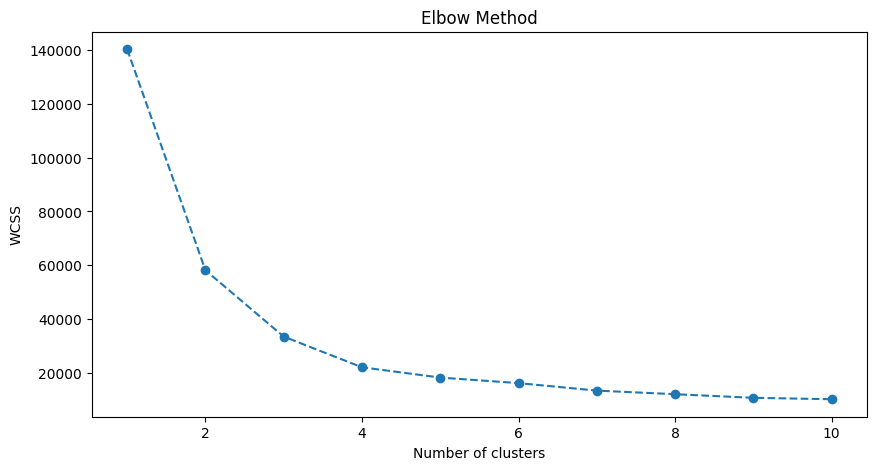

In [49]:
from sklearn.cluster import KMeans
wcss = []
# Menggunakan fitur yang sudah di-scale (CO2, Usage_kWh, NSM, Reactive Power)
features_for_clustering = ['Usage_kWh', 'CO2(tCO2)', 'NSM', 'Lagging_Current_Reactive.Power_kVarh']
X_cluster = df[features_for_clustering]

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


## 16. K-Means Clustering
**Analisis:** Dari grafik Elbow, patahan paling tajam biasanya di K=3. Kita akan mengelompokkan data ke dalam 3 klaster. Profil ini akan ditambahkan sebagai fitur baru `Cluster`.


In [50]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)

# Menampilkan rata-rata setiap fitur per klaster
cluster_summary = df.groupby('Cluster')[features_for_clustering].mean()
print(cluster_summary)


         Usage_kWh  CO2(tCO2)       NSM  Lagging_Current_Reactive.Power_kVarh
Cluster                                                                      
0         1.331602   1.325184  0.276429                              1.316833
1        -0.458504  -0.455368  0.949483                             -0.645777
2        -0.684740  -0.682250 -1.056379                             -0.508805


---


# Fase 2: Predictive Mining (Peramalan Konsumsi)
Kita menggunakan algoritma Machine Learning (Random Forest) untuk memprediksi besaran `Usage_kWh`.


## 17. Train-Test Split & Modeling
**Analisis:** Memisahkan data menjadi latih dan uji, lalu melatih model regresi.


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(['Usage_kWh', 'CO2(tCO2)'], axis=1)
y = df['Usage_kWh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-Squared (R2) Score: {r2:.4f}")


Root Mean Squared Error (RMSE): 0.0255
R-Squared (R2) Score: 0.9994


---


# Fase 3: Constraint-Based Recommendation System
Pendekatan **Knowledge-Based RS (Constraint-Based)** untuk optimasi kelistrikan pabrik.


## 18. Sistem Rekomendasi Interaktif
**Analisis:** Mensimulasikan pencarian database. Jika *constraint* user tidak menghasilkan opsi (0 results), sistem usulkan **repair proposals** (pelonggaran kriteria).


In [52]:
# Memuat ulang data mentah untuk dibaca manusia (tidak di-scale)
df_raw = pd.read_csv('Steel_industry.csv')
df_raw['Date_Time'] = pd.to_datetime(df_raw['Date_Time'], format='%d-%m-%Y %H:%M')
df_raw['Hour'] = df_raw['Date_Time'].dt.hour

def recommend_operations(max_kwh, max_co2, preferred_day):
    filtered = df_raw[
        (df_raw['Usage_kWh'] <= max_kwh) & 
        (df_raw['CO2(tCO2)'] <= max_co2) & 
        (df_raw['Day_Of_Week'].str.lower() == preferred_day.lower())
    ]
    
    if len(filtered) == 0:
        print("--- HASIL PENCARIAN KOSONG ---")
        print("Tidak ada konfigurasi operasional yang memenuhi semua batasan Anda.")
        print("\n[ SARAN PELONGGARAN / REPAIR PROPOSALS ]")
        
        relaxed_kwh = max_kwh * 1.2
        test_kwh = df_raw[(df_raw['Usage_kWh'] <= relaxed_kwh) & (df_raw['CO2(tCO2)'] <= max_co2) & (df_raw['Day_Of_Week'].str.lower() == preferred_day.lower())]
        if len(test_kwh) > 0:
            print(f"-> Jika Anda menaikkan batas Usage_kWh menjadi {relaxed_kwh:.2f}, kami menemukan {len(test_kwh)} opsi yang cocok.")
            
        test_day = df_raw[(df_raw['Usage_kWh'] <= max_kwh) & (df_raw['CO2(tCO2)'] <= max_co2) & (df_raw['Day_Of_Week'].isin(['Saturday', 'Sunday']))]
        if len(test_day) > 0:
            print(f"-> Jika Anda bersedia memindahkan operasional ke Akhir Pekan (Sabtu/Minggu), kami menemukan {len(test_day)} opsi yang cocok.")
        return
    
    best_options = filtered.sort_values(by='Usage_kWh').head(5)
    
    print(f"--- DITEMUKAN {len(filtered)} OPSI OPERASIONAL ---")
    print("Berikut adalah 5 rekomendasi konfigurasi terbaik untuk Anda:\n")
    
    for i, (_, row) in enumerate(best_options.iterrows(), 1):
        print(f"Rekomendasi {i}:")
        print(f"  - Mulai Operasional (Jam): {row['Hour']}:00 (NSM: {row['NSM']})")
        print(f"  - Load Type yang Dianjurkan: {row['Load_Type']}")
        print(f"  - Estimasi Penggunaan Listrik: {row['Usage_kWh']} kWh")
        print(f"  - Estimasi Emisi CO2: {row['CO2(tCO2)']} tCO2")
        print(f"  - Target Lagging Power Factor: {row['Lagging_Current_Power_Factor']}")
        print("-" * 40)


## 19. Uji Coba Rekomendasi
**Analisis:** Menguji sistem dengan kueri realistis dan kueri ketat.


In [53]:
print("=== UJI COBA 1: Kueri Normal ===")
recommend_operations(max_kwh=10, max_co2=0.01, preferred_day='Monday')

print("\n\n=== UJI COBA 2: Kueri Terlalu Ketat (Memicu Pelonggaran) ===")
recommend_operations(max_kwh=2, max_co2=0.00, preferred_day='Monday')


=== UJI COBA 1: Kueri Normal ===
--- DITEMUKAN 2656 OPSI OPERASIONAL ---
Berikut adalah 5 rekomendasi konfigurasi terbaik untuk Anda:

Rekomendasi 1:
  - Mulai Operasional (Jam): 6:00 (NSM: 24300)
  - Load Type yang Dianjurkan: Light_Load
  - Estimasi Penggunaan Listrik: 2.45 kWh
  - Estimasi Emisi CO2: 0.0 tCO2
  - Target Lagging Power Factor: 48.99
----------------------------------------
Rekomendasi 2:
  - Mulai Operasional (Jam): 6:00 (NSM: 23400)
  - Load Type yang Dianjurkan: Light_Load
  - Estimasi Penggunaan Listrik: 2.48 kWh
  - Estimasi Emisi CO2: 0.0 tCO2
  - Target Lagging Power Factor: 48.27
----------------------------------------
Rekomendasi 3:
  - Mulai Operasional (Jam): 7:00 (NSM: 25200)
  - Load Type yang Dianjurkan: Light_Load
  - Estimasi Penggunaan Listrik: 2.48 kWh
  - Estimasi Emisi CO2: 0.0 tCO2
  - Target Lagging Power Factor: 49.79
----------------------------------------
Rekomendasi 4:
  - Mulai Operasional (Jam): 23:00 (NSM: 85500)
  - Load Type yang Dianju